# 2025 BAMA-580A Group 18

## Load & Transform

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load the dataset
survey = pd.read_csv('MBAN+Grp+14-19_datafile_value.csv')

# show the column names
print(survey.columns)

Index(['StartDate', 'EndDate', 'Status', 'IPAddress', 'Progress',
       'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId',
       'RecipientLastName', 'RecipientFirstName', 'RecipientEmail',
       'ExternalReference', 'LocationLatitude', 'LocationLongitude',
       'DistributionChannel', 'UserLanguage', 'ID', 'Gain-Framed Message:_1',
       'Loss-Framed Message:_1', 'QID1217973024', 'Q4', 'Q5', 'Q6_1', 'Q11_1',
       'Q12_1', 'Q13_1', 'Q21_1', 'Q44_1', 'Q14', 'Q36_1', 'Q37_1', 'Q38_1',
       'Q39_1', 'Q45_1', 'Q40', 'Q16', 'Q17', 'Q18', 'Q1', 'Q2', 'Q1.1',
       'Q2.1', 'Q3', 'Q4.1', 'Q5.1', 'Q6', 'Q6_5_TEXT', 'Q4.2', 'Q5.2', 'Q6.1',
       'Q7', 'Q8', 'Q12', 'Q13', 'Q14.1', 'Q15', 'Q16.1', 'Q18.1', 'Q19',
       'Q20', 'Q36_First Click', 'Q36_Last Click', 'Q36_Page Submit',
       'Q36_Click Count', 'Q1.2', 'Q2.2', 'Q3.1', 'Q37_First Click',
       'Q37_Last Click', 'Q37_Page Submit', 'Q37_Click Count', 'Q1.3', 'Q2.3',
       'Q3.2', 'Q4.3', 'Q5.3', 'Q6.2', 'purc

In [2]:
# only keep the columns we need
survey = survey[['ResponseId', 'LocationLatitude', 'LocationLongitude', 
                 'Q36_First Click', 'Q36_Last Click', 'Q36_Page Submit', 'Q36_Click Count', 'Q1.2', 'Q2.2', 'Q3.1', 
                 'Q37_First Click', 'Q37_Last Click', 'Q37_Page Submit', 'Q37_Click Count', 'Q1.3', 'Q2.3', 'Q3.2', 
                 'Q4.3', 'Q5.3', 'Q6.2', 'Income_1', ]]

# Remove the first row
survey = survey.iloc[2:]
# reset the index
survey.reset_index(drop=True, inplace=True)

# check the data types, missing values, and unique values
print(survey.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ResponseId         302 non-null    object
 1   LocationLatitude   302 non-null    object
 2   LocationLongitude  302 non-null    object
 3   Q36_First Click    151 non-null    object
 4   Q36_Last Click     151 non-null    object
 5   Q36_Page Submit    151 non-null    object
 6   Q36_Click Count    151 non-null    object
 7   Q1.2               151 non-null    object
 8   Q2.2               151 non-null    object
 9   Q3.1               151 non-null    object
 10  Q37_First Click    151 non-null    object
 11  Q37_Last Click     151 non-null    object
 12  Q37_Page Submit    151 non-null    object
 13  Q37_Click Count    151 non-null    object
 14  Q1.3               151 non-null    object
 15  Q2.3               151 non-null    object
 16  Q3.2               151 non-null    object
 1

In [3]:
# Add a new column to the dataset based on whether missing values are present in survey['Q36_First Click']
survey['Group'] = np.where(survey['Q36_First Click'].isnull(), 'Sust', 'Dura')

# change the data types of the columns and rename them
survey['ResponseId'] = survey['ResponseId'].astype(str)
survey['LocationLatitude'] = survey['LocationLatitude'].astype(float)
survey['LocationLongitude'] = survey['LocationLongitude'].astype(float)
survey['Q36_First Click'] = survey['Q36_First Click'].astype(float)
survey['Q36_Last Click'] = survey['Q36_Last Click'].astype(float)
survey['Q36_Page Submit'] = survey['Q36_Page Submit'].astype(float)
survey['Q36_Click Count'] = survey['Q36_Click Count'].astype(float)
survey['Q37_First Click'] = survey['Q37_First Click'].astype(float)
survey['Q37_Last Click'] = survey['Q37_Last Click'].astype(float)
survey['Q37_Page Submit'] = survey['Q37_Page Submit'].astype(float)
survey['Q37_Click Count'] = survey['Q37_Click Count'].astype(float)

# convert the columns to categorical data types
survey['Q1.2'] = survey['Q1.2'].astype('category')
survey['Q2.2'] = survey['Q2.2'].astype('category')
survey['Q3.1'] = survey['Q3.1'].astype('category')
survey['Q1.3'] = survey['Q1.3'].astype('category')
survey['Q2.3'] = survey['Q2.3'].astype('category')
survey['Q3.2'] = survey['Q3.2'].astype('category')
survey['Q4.3'] = survey['Q4.3'].astype('category')
survey['Q5.3'] = survey['Q5.3'].astype('category')
survey['Q6.2'] = survey['Q6.2'].astype('category')

survey['Group'] = survey['Group'].astype('category')

# survey['Q1.2'] = survey['Q1.2'].astype(float)
# survey['Q2.2'] = survey['Q2.2'].astype(float)
# survey['Q3.1'] = survey['Q3.1'].astype(float)
# survey['Q1.3'] = survey['Q1.3'].astype(float)   
# survey['Q2.3'] = survey['Q2.3'].astype(float)
# survey['Q3.2'] = survey['Q3.2'].astype(float)


# Separate the dataset into two datasets, one for each question
survey_Dura = survey[['ResponseId', 'LocationLatitude', 'LocationLongitude', 
                 'Q36_First Click', 'Q36_Last Click', 'Q36_Page Submit', 'Q36_Click Count', 'Q1.2', 'Q2.2', 'Q3.1', 
                 'Q4.3', 'Q5.3', 'Q6.2', 'Group', 'Income_1']].copy().dropna()

survey_Sust = survey[['ResponseId', 'LocationLatitude', 'LocationLongitude', 
                 'Q37_First Click', 'Q37_Last Click', 'Q37_Page Submit', 'Q37_Click Count', 'Q1.3', 'Q2.3', 'Q3.2',
                 'Q4.3', 'Q5.3', 'Q6.2', 'Group', 'Income_1']].copy().dropna()
# save the datasets to csv files

# change the column names to match the original dataset
survey_Dura.rename(columns={'Q1.2': 'Q1', 
                            'Q2.2': 'Q2',
                            'Q3.1': 'Q3',
                            'Q4.3': 'Q4',
                            'Q5.3': 'Q5',
                            'Q6.2': 'Q6',}, inplace=True)
survey_Sust.rename(columns={'Q1.3': 'Q1',
                            'Q2.3': 'Q2',
                            'Q3.2': 'Q3',
                            'Q4.3': 'Q4',
                            'Q5.3': 'Q5',
                            'Q6.2': 'Q6',}, inplace=True)

# save the datasets to csv files
survey_Dura.to_csv('survey_Dura.csv', index=False)
survey_Sust.to_csv('survey_Sust.csv', index=False)

# combine the two datasets into one without the columns starting with Q36 and Q37
survey_A = survey_Dura.drop(columns=['Q36_First Click', 'Q36_Last Click', 'Q36_Page Submit', 'Q36_Click Count']).copy()
survey_B = survey_Sust.drop(columns=['Q37_First Click', 'Q37_Last Click', 'Q37_Page Submit', 'Q37_Click Count']).copy()
survey_combined = pd.concat([survey_A, survey_B], ignore_index=True)
survey_combined['Q1'] = survey_combined['Q1'].astype('category')

In [4]:
# Calculate the mean and standard deviation of columns in survey_Dura and survey_Sust
survey_Dura_mean = survey_Dura[['Q36_First Click', 'Q36_Last Click', 'Q36_Page Submit', 'Q36_Click Count', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6']].copy().astype('float').mean()
survey_Dura_std = survey_Dura[['Q36_First Click', 'Q36_Last Click', 'Q36_Page Submit', 'Q36_Click Count', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6']].copy().astype('float').std()
survey_Sust_mean = survey_Sust[['Q37_First Click', 'Q37_Last Click', 'Q37_Page Submit', 'Q37_Click Count', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6']].copy().astype('float').mean()
survey_Sust_std = survey_Sust[['Q37_First Click', 'Q37_Last Click', 'Q37_Page Submit', 'Q37_Click Count', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6']].copy().astype('float').std()
# Create a new DataFrame to store the means and standard deviations
survey_means = pd.DataFrame({
    'Dura_Mean': survey_Dura_mean,
    'Dura_Std': survey_Dura_std,
    'Sust_Mean': survey_Sust_mean,
    'Sust_Std': survey_Sust_std
})

print(survey_means)

                 Dura_Mean   Dura_Std  Sust_Mean   Sust_Std
Q1                4.066225   0.861540   4.245033   0.652859
Q2                3.357616   1.250836   3.463576   1.204297
Q3                3.245033   1.194247   3.417219   1.028641
Q36_Click Count   3.887417   2.183401        NaN        NaN
Q36_First Click   8.666510  15.318159        NaN        NaN
Q36_Last Click   15.102563  20.155363        NaN        NaN
Q36_Page Submit  16.399079  20.115940        NaN        NaN
Q37_Click Count        NaN        NaN   4.450331   2.760891
Q37_First Click        NaN        NaN   9.461464  22.691730
Q37_Last Click         NaN        NaN  17.939702  28.093937
Q37_Page Submit        NaN        NaN  19.460589  28.152088
Q4                1.569536   0.510032   1.543046   0.499801
Q5                2.543046   0.745968   2.589404   0.896449
Q6                2.092715   0.545906   2.099338   0.538578


## Exploratory Analysis
### Main Effect on Distribution of the Response

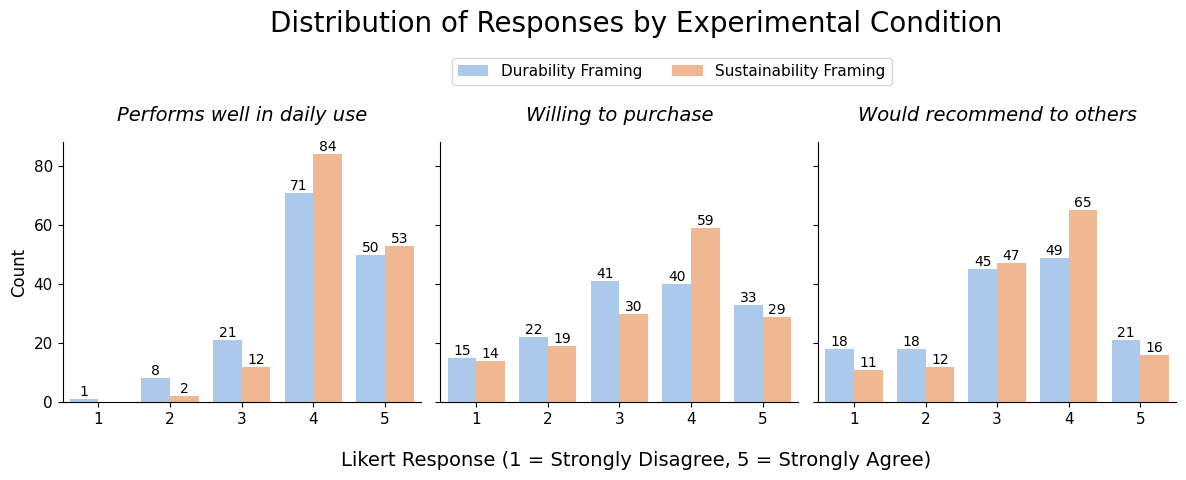

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Melt the data into long format
long_df = survey_combined.melt(
    id_vars='Group',
    value_vars=['Q1', 'Q2', 'Q3'],
    var_name='Question',
    value_name='Response'
)

# Set Likert scale order and question text mappings
likert_order = ['1', '2', '3', '4', '5']
long_df['Response'] = long_df['Response'].astype('category').cat.set_categories(likert_order, ordered=True)
long_df['Question'] = long_df['Question'].map({
    'Q1': "Performs well in daily use",
    'Q2': "Willing to purchase",
    'Q3': "Would recommend to others"
})
long_df['Group'] = long_df['Group'].map({
    'Dura': 'Durability Framing',
    'Sust': 'Sustainability Framing'
})

# Create the FacetGrid plot
g = sns.catplot(
    data=long_df,
    kind="count",
    x="Response",
    hue="Group",
    col="Question",
    order=likert_order,
    palette="pastel",
    height=4,
    aspect=1,
    sharey=True,
    sharex=True
)

# Set subplot titles and remove individual x-axis labels
g.set_titles("{col_name}", size=14, style='italic', y=1.05)
for ax in g.axes.flat:
    ax.set_xlabel("")
    ax.tick_params(axis='both', labelsize=11)  # adjust tick label size

# Set y-axis label and overall title
g.set_ylabels("Count", size=12)
g.fig.subplots_adjust(bottom=0.2, top=0.85)
g.fig.suptitle("Distribution of Responses by Experimental Condition", fontsize=20, x=0.46, y=1.18)

# Common x-axis label
g.fig.text(0.46, 0.04,
           "Likert Response (1 = Strongly Disagree, 5 = Strongly Agree)",
           ha='center', fontsize=14)

# Annotate each bar with count
for ax in g.axes.flat:
    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        (bar.get_x() + bar.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=10)

# Remove and rebuild a clean horizontal legend
g._legend.remove()
handles, labels = [], []
for ax in g.axes.flat:
    handles, labels = ax.get_legend_handles_labels()
    if handles:  # stop when we find a valid set
        break

# Recreate the horizontal legend
g.fig.legend(
    handles,
    labels,
    bbox_to_anchor=(0.485, 1.08),
    loc="upper center",
    ncol=2,
    frameon=True,
    fontsize=11,
    title_fontsize=12
)

# Save the plot
g.savefig("combined_Q1_Q2_Q3_distribution_named.png", dpi=600, bbox_inches='tight', transparent=False)
plt.show()

In [6]:
# Exploring Data Analysis

# Show the location of each sample in a map
# Install missing dependencies
%pip install folium

import folium
from folium.plugins import MarkerCluster

# Create a map centered around the average latitude and longitude
map_center = [survey['LocationLatitude'].mean(), survey['LocationLongitude'].mean()]
m = folium.Map(location=map_center, zoom_start=2)
marker_cluster = MarkerCluster().add_to(m)
# Add points to the map
for idx, row in survey.iterrows():
    folium.Marker(
        location=[row['LocationLatitude'], row['LocationLongitude']],
        popup=f"ResponseId: {row['ResponseId']}, Group: {row['Group']}",
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(marker_cluster)
# Save the map to an HTML file
m.save('survey_map.html')
# Load the map and display it
import webbrowser
webbrowser.open('survey_map.html')

Note: you may need to restart the kernel to use updated packages.


True

### Main Effect on Mean of the Response

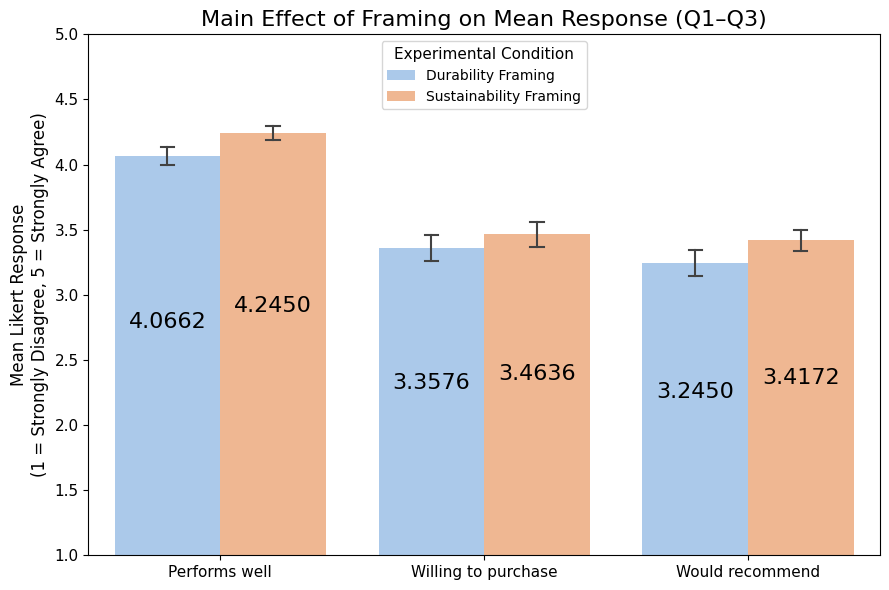

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure Q1–Q3 are numeric
mean_df = survey_combined.copy()
for col in ['Q1', 'Q2', 'Q3']:
    mean_df[col] = mean_df[col].astype(float)

# Melt into long format
long_mean_df = mean_df.melt(
    id_vars='Group',
    value_vars=['Q1', 'Q2', 'Q3'],
    var_name='Question',
    value_name='Response'
)

# Map question labels
question_text_map = {
    'Q1': 'Performs well',
    'Q2': 'Willing to purchase',
    'Q3': 'Would recommend'
}
long_mean_df['Question'] = long_mean_df['Question'].map(question_text_map)

# Map group labels
long_mean_df['Group'] = long_mean_df['Group'].map({
    'Dura': 'Durability Framing',
    'Sust': 'Sustainability Framing'
})

# Plot the means with standard error bars (Seaborn ≥ 0.12 style)
plt.figure(figsize=(9, 6))
ax = sns.barplot(
    data=long_mean_df,
    x='Question',
    y='Response',
    hue='Group',
    palette='pastel',
    errorbar=("se", 1), 
    capsize=0.1,
    err_kws={'linewidth': 1.5} 
)

# Annotate each bar with its mean value
for bar in ax.patches:
    height = bar.get_height()
    if not pd.isna(height):
        ax.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, 0.66 * height),
                    xytext=(0, 3),  # vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=16)
        
# Plot titles and labels
plt.title("Main Effect of Framing on Mean Response (Q1–Q3)", fontsize=16)
plt.ylabel("Mean Likert Response\n(1 = Strongly Disagree, 5 = Strongly Agree)", fontsize=12)
plt.xlabel("")
plt.ylim(1, 5)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Experimental Condition", fontsize=10, title_fontsize=11, loc='upper center')
plt.tight_layout()

# Save and show
plt.savefig("main_effect_mean_Q1_Q2_Q3.png", dpi=600, bbox_inches='tight')
plt.show()

# Result 1: Test on the difference of means of Q1

In [8]:
from scipy.stats import ttest_ind
from statsmodels.stats.power import TTestIndPower
import numpy as np

# Function to calculate Cohen's d effect size
def cohen_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx - 1) * x.std()**2 + (ny - 1) * y.std()**2) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_std

# Function to calculate the power of the t-test
def calculate_power(n1, n2, d, alpha=0.05):
    analysis = TTestIndPower()
    total_n = n1 + n2
    power = analysis.solve_power(effect_size=d, nobs1=n1, ratio=n1/n2, alpha=alpha, alternative='two-sided')
    return power


def calculate_minimum_sample_size(effect_size, alpha=0.05, power=0.8):
    analysis = TTestIndPower()
    sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power)
    return int(np.ceil(sample_size))

# Questions to test
questions = ['Q1', 'Q2', 'Q3']

print("T-test results comparing Durability vs. Sustainability Framing:\n")

for q in questions:
    # Extract data
    dura_vals = survey_combined[survey_combined['Group'] == 'Dura'][q].astype(float).dropna()
    sust_vals = survey_combined[survey_combined['Group'] == 'Sust'][q].astype(float).dropna()
      
    # Sample sizes
    n_dura = len(dura_vals)
    n_sust = len(sust_vals)
    
    # Run Welch's t-test to compare means
    t_stat, p_val = ttest_ind(dura_vals, sust_vals, equal_var=False)
    
    # Effect size to interpret the difference
    d = cohen_d(dura_vals, sust_vals)
    
    # Calculate power
    power = calculate_power(n_dura, n_sust, d)
    
    
    # Display results
    print(f"{q}:")
    print(f"  Sample size (Durability): {n_dura}")
    print(f"  Sample size (Sustainability): {n_sust}")
    print(f"  Mean (Durability):     {dura_vals.mean():.2f}")
    print(f"  Mean (Sustainability): {sust_vals.mean():.2f}")
    print(f"  T-statistic: {t_stat:.3f}")
    print(f"  P-value:     {p_val:.4f}")
    print(f"  Cohen's d:   {d:.3f}")
    print(f"  Power:       {power:.3f}")
    print(f"  Minimum sample size needed for power of 0.8: {calculate_minimum_sample_size(d)}")
    if p_val < 0.05:
        print("  Significant difference\n")
    else:
        print("  Not significant\n")

T-test results comparing Durability vs. Sustainability Framing:

Q1:
  Sample size (Durability): 151
  Sample size (Sustainability): 151
  Mean (Durability):     4.07
  Mean (Sustainability): 4.25
  T-statistic: -2.033
  P-value:     0.0430
  Cohen's d:   -0.234
  Power:       0.526
  Minimum sample size needed for power of 0.8: 288
  Significant difference

Q2:
  Sample size (Durability): 151
  Sample size (Sustainability): 151
  Mean (Durability):     3.36
  Mean (Sustainability): 3.46
  T-statistic: -0.750
  P-value:     0.4539
  Cohen's d:   -0.086
  Power:       0.116
  Minimum sample size needed for power of 0.8: 2109
  Not significant

Q3:
  Sample size (Durability): 151
  Sample size (Sustainability): 151
  Mean (Durability):     3.25
  Mean (Sustainability): 3.42
  T-statistic: -1.342
  P-value:     0.1805
  Cohen's d:   -0.154
  Power:       0.268
  Minimum sample size needed for power of 0.8: 659
  Not significant



## Test if the effect of Group on Q1 is moderated by Q4 ( gender )
Hypothesis:
1.	Dependent variable: Q1
2.	Independent variable: Group (Durability vs. Sustainability Framing)
3.	Moderator: Q4 (Gender)

In [9]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Check value counts
print("Group:", survey_combined['Group'].value_counts())
print("Q4:", survey_combined['Q4'].value_counts())
print("Q1 missing:", survey_combined['Q1'].isna().sum())

# Filter out Q4 responses with count < 2
filtered_df = survey_combined[
    (survey_combined['Q4'].isin(['1', '2'])) &  # keep only valid Q4s
    (~survey_combined['Q1'].isna())
].copy()

# Ensure correct types
filtered_df['Group'] = filtered_df['Group'].astype('category')
filtered_df['Q4'] = filtered_df['Q4'].cat.remove_unused_categories()
filtered_df['Q4'] = filtered_df['Q4'].astype('category')
filtered_df['Q1'] = filtered_df['Q1'].astype(float)

# Rerun ANOVA
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.ols('Q1 ~ C(Group) * C(Q4)', data=filtered_df).fit()
# Two way ANOVA 
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


Group: Group
Dura    151
Sust    151
Name: count, dtype: int64
Q4: Q4
2    166
1    135
3      1
Name: count, dtype: int64
Q1 missing: 0
                    sum_sq     df         F    PR(>F)
C(Group)          2.358655    1.0  4.008682  0.046176
C(Q4)             0.435401    1.0  0.739992  0.390357
C(Group):C(Q4)    0.080893    1.0  0.137483  0.711061
Residual        174.750814  297.0       NaN       NaN


Result:

- Framing matters: Participants who saw Sustainability or Durability messages rated product performance (Q1) differently — so the way the message was framed impacted perception.
- Gender doesn’t matter by itself: Men and women rated the product similarly on average.
- No moderation: The framing effect is consistent across both genders — it doesn’t work better for one group than the other.

In [10]:
# Recode into binary: Disagree (1–2) vs. Agree (3–5)
def recode_q2(x):
    x = int(x)
    if x <= 3:
        return 0  # 0 = Disagree
    elif x == 4:
        return 1
    elif x == 5:
        return 2


q2 = survey_combined[['Q2', 'Group']].dropna().copy()
q2['Q2'] = q2['Q2'].astype(int).apply(recode_q2)

# Run logistic regression
import statsmodels.formula.api as smf

modelQ2 = smf.ols('Q2 ~ C(Group)', data=q2).fit()
print(modelQ2.summary())

# Odds ratio interpretation
import numpy as np
odds_ratio = np.exp(modelQ2.params['C(Group)[T.Sust]'])
print(f"Odds Ratio (Sust vs. Dura): {odds_ratio:.3f}")

                            OLS Regression Results                            
Dep. Variable:                     Q2   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.6607
Date:                Fri, 11 Apr 2025   Prob (F-statistic):              0.417
Time:                        16:51:00   Log-Likelihood:                -352.00
No. Observations:                 302   AIC:                             708.0
Df Residuals:                     300   BIC:                             715.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.7020      0.063  

# Result 2: OLS Regression Q2 ~ Group on samples from Califonia

## Q2 ~ Group on samples from Califonia & NewYork

In [11]:
#%pip install statsmodels
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.power import TTestIndPower

# Classify states based on lat/lon
def classify_state(lat, lon):
    try:
        lat = float(lat)
        lon = float(lon)
        if 32 <= lat <= 42 and -125 <= lon <= -114:
            return 'California'
        elif 40 <= lat <= 45 and -80 <= lon <= -71:
            return 'New York'
        else:
            return 'Other'
    except:
        return 'Unknown'

# Assign state
survey_combined['State'] = survey_combined.apply(
    lambda row: classify_state(row['LocationLatitude'], row['LocationLongitude']), axis=1
)

# Filter only California and New York
state_df = survey_combined[survey_combined['State'].isin(['California', 'New York'])].copy()
state_df['Q2'] = pd.to_numeric(state_df['Q2'], errors='coerce')
state_df['Group'] = state_df['Group'].astype('category')

# Initialize power calculator
power_calc = TTestIndPower()

# Run analysis by state
for state in ['California', 'New York']:
    print(f"\n=== OLS Regression for {state} ===")
    sub = state_df[state_df['State'] == state].dropna(subset=['Q2', 'Group'])
    
    # Run OLS
    model = smf.ols('Q2 ~ C(Group)', data=sub).fit()
    print(model.summary())

    # Compute effect size f²
    r_squared = model.rsquared
    f_squared = r_squared / (1 - r_squared) if r_squared < 1 else 0

    # Compute power
    n = len(sub)
    power = power_calc.power(effect_size=np.sqrt(f_squared), nobs1=n, alpha=0.05, ratio=1.0)
    
    print(f"\n=== Power Analysis ===")
    print(f"Sample size (n): {n}")
    print(f"R-squared: {r_squared:.4f}")
    print(f"Cohen’s f²: {f_squared:.4f}")
    print(f"Post-hoc power (α=0.05): {power:.3f}")
    
    # show the table of number of samples in each group
    print("\n=== Sample Sizes ===")
    print(sub['Group'].value_counts())


=== OLS Regression for California ===
                            OLS Regression Results                            
Dep. Variable:                     Q2   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.120
Method:                 Least Squares   F-statistic:                     4.400
Date:                Fri, 11 Apr 2025   Prob (F-statistic):             0.0467
Time:                        16:51:00   Log-Likelihood:                -36.581
No. Observations:                  26   AIC:                             77.16
Df Residuals:                      24   BIC:                             79.68
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
I

## Bootstrap for Samples in Califonia

In [12]:
import numpy as np
import pandas as pd

# Filter only California
cal_df = survey_combined[survey_combined['State'] == 'California'].copy()

# Clean and subset
cal_df['Q2'] = pd.to_numeric(cal_df['Q2'], errors='coerce')
cal_df = cal_df.dropna(subset=['Q2', 'Group'])

# Extract values
q2_dura = cal_df[cal_df['Group'] == 'Dura']['Q2'].values
q2_sust = cal_df[cal_df['Group'] == 'Sust']['Q2'].values

# Bootstrapping
n_boot = 10000
boot_diffs = np.empty(n_boot)
np.random.seed(42)

for i in range(n_boot):
    sample_dura = np.random.choice(q2_dura, size=len(q2_dura), replace=True)
    sample_sust = np.random.choice(q2_sust, size=len(q2_sust), replace=True)
    boot_diffs[i] = sample_sust.mean() - sample_dura.mean()

# Confidence Interval
ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)
mean_diff = np.mean(boot_diffs)
prop_above_zero = np.mean(boot_diffs > 0)

# Results
print(f"California Bootstrapped Mean Difference (Sust - Dura): {mean_diff:.3f}")
print(f"95% Confidence Interval: [{ci_lower:.3f}, {ci_upper:.3f}]")
print(f"Proportion of samples where Sust > Dura: {prop_above_zero:.2%}")

if ci_lower > 0 or ci_upper < 0:
    print("CI does not include 0 → Significant difference!")
else:
    print("CI includes 0 → Not statistically significant.")

California Bootstrapped Mean Difference (Sust - Dura): 0.842
95% Confidence Interval: [0.077, 1.615]
Proportion of samples where Sust > Dura: 98.40%
CI does not include 0 → Significant difference!


## Q2 ~ Group on samples from Califonia

In [13]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Step 1: Subset to non-missing Q2, Q4, Q5
df = survey_combined[
    (survey_combined['Q4'].isin(['1', '2'])) &
    (survey_combined['Q5'].notna()) &
    (~survey_combined['Q2'].isna())
].copy()

# Step 2: Ensure proper data types
df['Q2'] = pd.to_numeric(df['Q2'], errors='coerce')
df['Group'] = df['Group'].astype('category')
df['Q4'] = df['Q4'].astype('category')
df['Q5'] = df['Q5'].astype('category')

# Optional: remove unused Q4 categories
df['Q4'] = df['Q4'].cat.remove_unused_categories()

# Step 3: Fit OLS model with three-way interaction
formula = 'Q2 ~ C(Group) * C(Q4) * C(Q5)'
model = smf.ols(formula, data=df).fit()

# Step 4: Show results
print("OLS Regression Summary:")
print(model.summary())

# Step 5: ANOVA table
print("Three-Way ANOVA Table (Type II):")
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# Step 6: Sample size breakdown
print("Sample Sizes:")
print("Group:\n", df['Group'].value_counts())
print("Q4:\n", df['Q4'].value_counts())
print("Q5:\n", df['Q5'].value_counts())

OLS Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                     Q2   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     1.514
Date:                Fri, 11 Apr 2025   Prob (F-statistic):             0.0992
Time:                        16:51:00   Log-Likelihood:                -476.45
No. Observations:                 301   AIC:                             984.9
Df Residuals:                     285   BIC:                             1044.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

                          sum_sq     df         F    PR(>F)
C(Group)                1.075724    1.0  0.733795  0.392375
C(Q4)                   0.352125    1.0  0.240199  0.624439
C(Q5)                  47.353175    4.0  8.075382  0.000035
C(Group):C(Q4)          0.304474    1.0  0.207694  0.648928
C(Group):C(Q5)          4.216415    4.0  0.719047  0.541309
C(Q4):C(Q5)             4.362636    4.0  0.743983  0.526621
C(Group):C(Q4):C(Q5)   17.751905    4.0  3.027324  0.018107
Residual              417.802382  285.0       NaN       NaN
Sample Sizes:
Group:
 Group
Sust    151
Dura    150
Name: count, dtype: int64
Q4:
 Q4
2    166
1    135
Name: count, dtype: int64
Q5:
 Q5
2    151
3     89
4     45
1     14
5      2
Name: count, dtype: int64


/opt/anaconda3/envs/Sauder_MBAN/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/envs/Sauder_MBAN/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/envs/Sauder_MBAN/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '


# Result 3: Two-way ANOVA(Framings × Environmental Concern(Q6) → Purchase Intention (Q2))

## ANOVA on Q2 ~ Group * Q4/Q5/Q6

In [14]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Define moderators
moderators = ['Q4', 'Q5', 'Q6']

for mod in moderators:
    print(f"\n\n==========================")
    print(f"TWO-WAY ANOVA: Q2 ~ Group * {mod}")
    print("==========================")

    # Conditional filtering for Q4 only
    if mod == 'Q4':
        df = survey_combined[
            (survey_combined[mod].isin(['1', '2'])) &
            (~survey_combined['Q2'].isna())
        ].copy()
        df[mod] = df[mod].astype('category')
        df[mod] = df[mod].cat.remove_unused_categories()
    else:
        df = survey_combined[~survey_combined['Q2'].isna()].copy()
        df[mod] = df[mod].astype('category')

    # Ensure correct types
    df['Group'] = df['Group'].astype('category')
    df['Q2'] = pd.to_numeric(df['Q2'], errors='coerce')

    # Fit OLS model
    formula = f'Q2 ~ C(Group) * C({mod})'
    model = smf.ols(formula, data=df).fit()

    # Print OLS regression summary
    print("OLS Regression Summary:")
    print(model.summary())

    # Print ANOVA table
    print("ANOVA Table (Type II):")
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)

    # Sample sizes
    print("Sample sizes:")
    print(df['Group'].value_counts(), "\n")
    print(df[mod].value_counts())



TWO-WAY ANOVA: Q2 ~ Group * Q4
OLS Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                     Q2   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                    0.4549
Date:                Fri, 11 Apr 2025   Prob (F-statistic):              0.714
Time:                        16:51:00   Log-Likelihood:                -487.30
No. Observations:                 301   AIC:                             982.6
Df Residuals:                     297   BIC:                             997.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

/opt/anaconda3/envs/Sauder_MBAN/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '


In [15]:

# Data preparation
df = survey_combined.copy()
df = df.dropna(subset=["Group", "Q2", "Q4", "Q5", "Q6"])
df["Group"] = df["Group"].map({"Dura": 0, "Sust": 1}).astype(int)
df["Q2"] = df["Q2"].astype(float)
df["Q4"] = df["Q4"].astype("category")
df["Q5"] = df["Q5"].astype("category")
df["Q6_num"] = df["Q6"].astype(float)
df["Q6_cat"] = df["Q6"].astype("category")  # For grouped version

# 1. One-way ANOVA: Group → Q2
print("One-way ANOVA: Group → Q2")
model1 = smf.ols("Q2 ~ C(Group)", data=df).fit()
print(sm.stats.anova_lm(model1, typ=2))

# 2. Two-way ANOVA: Group × Q6 (continuous)
print("Two-way ANOVA: Group × Q6 (continuous)")
model2 = smf.ols("Q2 ~ C(Group) * Q6_num", data=df).fit()
print(sm.stats.anova_lm(model2, typ=2))

# 3. Two-way ANOVA: Group × Q6 (categorical)
print("Two-way ANOVA: Group × Q6 (categorical)")
model3 = smf.ols("Q2 ~ C(Group) * C(Q6_cat)", data=df).fit()
print(sm.stats.anova_lm(model3, typ=2))

# 4. Two-way ANOVA: Group × Q4 (Gender)
print("Two-way ANOVA: Group × Q4 (Gender)")
model4 = smf.ols("Q2 ~ C(Group) * C(Q4)", data=df).fit()
print(sm.stats.anova_lm(model4, typ=2))

# 5. Two-way ANOVA: Group × Q5 (Age)
print("Two-way ANOVA: Group × Q5 (Age)")
model5 = smf.ols("Q2 ~ C(Group) * C(Q5)", data=df).fit()
print(sm.stats.anova_lm(model5, typ=2))


One-way ANOVA: Group → Q2
              sum_sq     df         F    PR(>F)
C(Group)    0.847682    1.0  0.562324  0.453913
Residual  452.238411  300.0       NaN       NaN
Two-way ANOVA: Group × Q6 (continuous)
                     sum_sq     df         F    PR(>F)
C(Group)           0.836827    1.0  0.563000  0.453646
Q6_num             0.926369    1.0  0.623242  0.430473
C(Group):Q6_num    8.373279    1.0  5.633368  0.018256
Residual         442.938762  298.0       NaN       NaN
Two-way ANOVA: Group × Q6 (categorical)
                        sum_sq     df         F    PR(>F)
C(Group)              0.801138    1.0  0.549710  0.459024
C(Q6_cat)             5.484445    2.0  1.881608  0.154163
C(Group):C(Q6_cat)   15.368791    2.0  5.272738  0.005622
Residual            431.385175  296.0       NaN       NaN
Two-way ANOVA: Group × Q4 (Gender)
                    sum_sq     df         F    PR(>F)
C(Group)               NaN    1.0       NaN       NaN
C(Q4)             4.066079    2.0  1.344715

/opt/anaconda3/envs/Sauder_MBAN/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1, but rank is 0
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/envs/Sauder_MBAN/lib/python3.12/site-packages/statsmodels/base/model.py:1923: RuntimeWarning: invalid value encountered in divide
  F /= J
/opt/anaconda3/envs/Sauder_MBAN/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/envs/Sauder_MBAN/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/envs/Sauder_MBAN/lib/python

/var/folders/c1/pzzqhqv11rbf4wy208f3y7xw0000gn/T/ipykernel_37065/3043617356.py:9: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.pointplot(


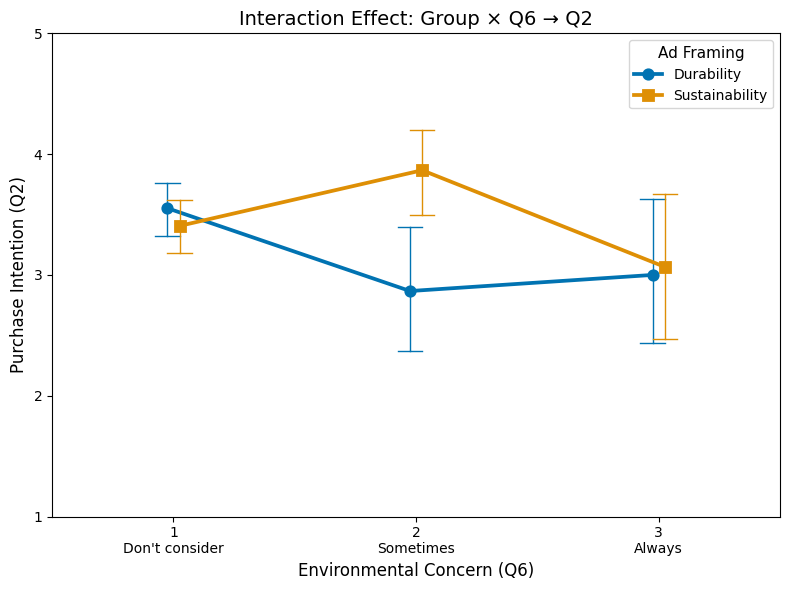

In [16]:
# Prepare data
df_plot = survey_combined.dropna(subset=["Group", "Q2", "Q6"]).copy()
df_plot["Group"] = df_plot["Group"].map({"Dura": "Durability", "Sust": "Sustainability"})
df_plot["Q6"] = df_plot["Q6"].astype(str)
df_plot["Q2"] = df_plot["Q2"].astype(float)

# Plot
plt.figure(figsize=(8, 6))
sns.pointplot(
    x="Q6", y="Q2", hue="Group",
    data=df_plot,
    dodge=True,
    markers=["o", "s"],
    capsize=0.1,
    errwidth=1,
    palette="colorblind"
)

# Set labels and style
plt.title("Interaction Effect: Group × Q6 → Q2", fontsize=14)
plt.xlabel("Environmental Concern (Q6)", fontsize=12)
plt.ylabel("Purchase Intention (Q2)", fontsize=12)
plt.ylim(1, 5)
plt.yticks([1, 2, 3, 4, 5])  # Set Y-axis to integer ticks
plt.xticks(ticks=[0, 1, 2], labels=["1\nDon't consider", "2\nSometimes", "3\nAlways"])
plt.legend(title="Ad Framing", title_fontsize=11, fontsize=10)
plt.tight_layout()
plt.show()


# Result 4: Three-way ANOVA (Framings × Gender (Q4) × Age (Q5) → Purchase Intention (Q2))

In [17]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Step 1: Subset to non-missing Q2, Q4, Q5
df = survey_combined[
    (survey_combined['Q4'].isin(['1', '2'])) &
    (survey_combined['Q5'].notna()) &
    (~survey_combined['Q2'].isna())
].copy()

# Step 2: Ensure proper data types
df['Q2'] = pd.to_numeric(df['Q2'], errors='coerce')
df['Group'] = df['Group'].astype('category')
df['Q4'] = df['Q4'].astype('category')
df['Q5'] = df['Q5'].astype('category')

# Optional: remove unused Q4 categories
df['Q4'] = df['Q4'].cat.remove_unused_categories()

# Step 3: Fit OLS model with three-way interaction
formula = 'Q2 ~ C(Group) * C(Q4) * C(Q5)'
model = smf.ols(formula, data=df).fit()

# Step 4: Show results
print("OLS Regression Summary:")
print(model.summary())

# Step 5: ANOVA table
print("Three-Way ANOVA Table (Type II):")
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# Step 6: Sample size breakdown
print("Sample Sizes:")
print("Group:\n", df['Group'].value_counts())
print("Q4:\n", df['Q4'].value_counts())
print("Q5:\n", df['Q5'].value_counts())

OLS Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                     Q2   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     1.514
Date:                Fri, 11 Apr 2025   Prob (F-statistic):             0.0992
Time:                        16:51:01   Log-Likelihood:                -476.45
No. Observations:                 301   AIC:                             984.9
Df Residuals:                     285   BIC:                             1044.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

/opt/anaconda3/envs/Sauder_MBAN/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/envs/Sauder_MBAN/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/envs/Sauder_MBAN/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '


In [18]:
# Filter the DataFrame to include only relevant columns and drop rows with missing values
df_q245 = df.dropna(subset=["Q2", "Q4", "Q5", "Group"]).copy()

# Ensure proper data types
df_q245["Q2"] = pd.to_numeric(df_q245["Q2"], errors="coerce")
df_q245["Q4"] = df_q245["Q4"].astype("category")
df_q245["Q5"] = df_q245["Q5"].astype("category")
df_q245["Group"] = df_q245["Group"].astype("category")

# Perform the three-way ANOVA
model_q245 = smf.ols("Q2 ~ C(Group) * C(Q4) * C(Q5)", data=df_q245).fit()
anova_q245 = sm.stats.anova_lm(model_q245, typ=3)
print("Three-way ANOVA: Group × Q4 × Q5 → Q2")
print(anova_q245)


Three-way ANOVA: Group × Q4 × Q5 → Q2
                          sum_sq     df          F        PR(>F)
Intercept              74.068674    1.0  50.525255  9.476316e-12
C(Group)                0.306809    1.0   0.209287  6.476752e-01
C(Q4)                   2.732839    1.0   1.864181  1.732198e-01
C(Q5)                   7.125786    4.0   1.215197  3.044714e-01
C(Group):C(Q4)          0.783789    1.0   0.534654  4.652574e-01
C(Group):C(Q5)          4.985236    4.0   0.850158  4.944370e-01
C(Q4):C(Q5)            11.763274    4.0   2.006052  9.376439e-02
C(Group):C(Q4):C(Q5)   17.751905    4.0   3.027324  1.810673e-02
Residual              417.802382  285.0        NaN           NaN


/var/folders/c1/pzzqhqv11rbf4wy208f3y7xw0000gn/T/ipykernel_37065/3382873588.py:38: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  g = sns.catplot(


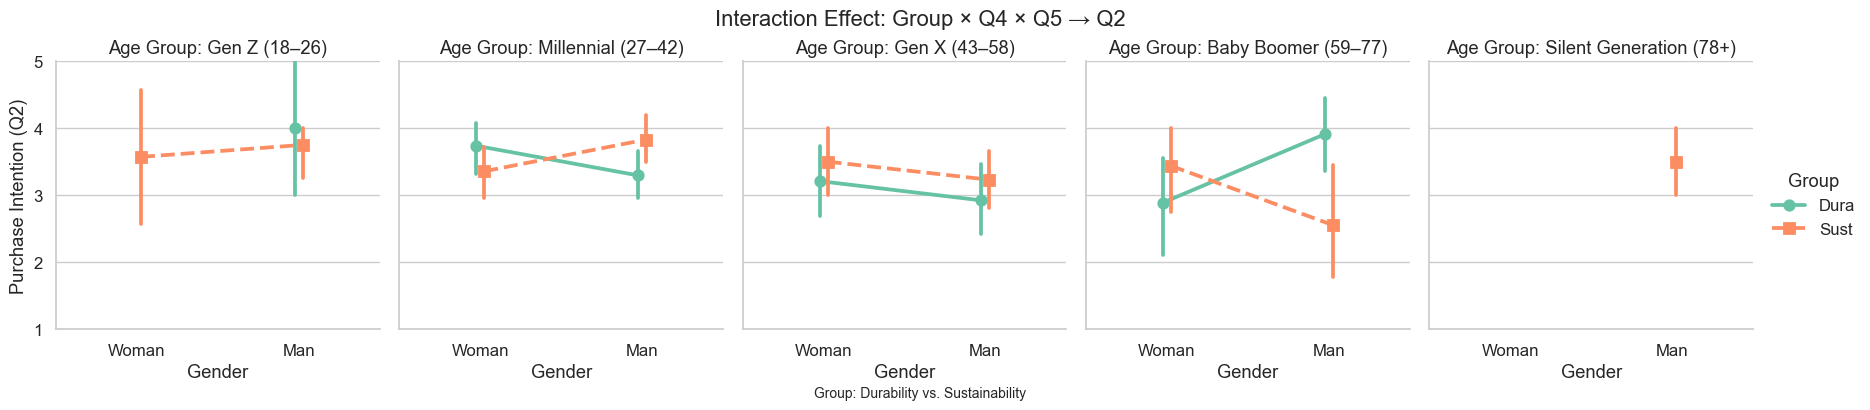

In [19]:
# Ensure Q4 and Q5 are categorical variables
df["Q4"] = df["Q4"].astype("category")
df["Q5"] = df["Q5"].astype("category")

# Define gender and age label mappings
gender_labels = {
    "1": "Woman",
    "2": "Man",
    "3": "Others"
}

age_labels = {
    "1": "Gen Z (18–26)",
    "2": "Millennial (27–42)",
    "3": "Gen X (43–58)",
    "4": "Baby Boomer (59–77)",
    "5": "Silent Generation (78+)"
}

# Replace category labels
df["Q4"] = df["Q4"].cat.rename_categories(gender_labels)
df["Q5"] = df["Q5"].cat.rename_categories(age_labels)

# Replace Group with meaningful labels
group_labels = {
    0: "Durability",
    1: "Sustainability"
}
df["Group"] = df["Group"].replace(group_labels)

# Filter out rows where gender is not Woman or Man
filtered_df = df[df["Q4"].isin(["Woman", "Man"])]

# Set style
sns.set(style="whitegrid", font_scale=1.1)

# Plot
g = sns.catplot(
    data=filtered_df,
    kind="point",
    x="Q4",
    y="Q2",
    hue="Group",
    col="Q5",
    dodge=True,
    ci=95,
    palette="Set2",
    height=4,
    aspect=0.9,
    markers=["o", "s"],
    linestyles=["-", "--"]
)

# Set chart titles and labels
g.set_axis_labels("Gender", "Purchase Intention (Q2)")
g.set_titles("Age Group: {col_name}")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Interaction Effect: Group × Q4 × Q5 → Q2")

# Add legend description
g.fig.text(0.5, 0.01, 'Group: Durability vs. Sustainability', ha='center', fontsize=10)

# Limit y-axis range
plt.ylim(1, 5)
plt.show()
